In [1]:
# Vérifier GPU et versions
import torch, sys
print("Python:", sys.version)
print("Torch:", torch.__version__, "| CUDA dispo:", torch.cuda.is_available(), "| CUDA version:", torch.version.cuda)
from cellpose import models
import matplotlib.pyplot as plt

Python: 3.11.7 (main, Jan 27 2026, 00:00:00) [GCC 11.4.1 20231218 (Red Hat 11.4.1-4)]
Torch: 2.10.0+cu128 | CUDA dispo: True | CUDA version: 12.8


Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.5 
platform:       	linux 
python version: 	3.11.7 
torch version:  	2.10.0+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




In [2]:
from pathlib import Path

# 📂 Définir les dossiers (adapte si besoin)
IMAGES_DIR = Path.home() / "cellpose" / "fine tuning" / "cellpose_data" / "images"
MASKS_DIR  = Path.home() / "cellpose" / "fine tuning" / "cellpose_data" / "masks"

# Lister les fichiers .tif
images = sorted(IMAGES_DIR.glob("*.tif"))
masks  = sorted(MASKS_DIR.glob("*.tif"))

# Afficher résultats
print(f"Nombre d'images dans {IMAGES_DIR}: {len(images)}")
for img in images:
    print(" -", img.name)

print(f"\nNombre de masques dans {MASKS_DIR}: {len(masks)}")
for m in masks:
    print(" -", m.name)


Nombre d'images dans /home/bc/bc_bc/bc_topalian/cellpose/fine tuning/cellpose_data/images: 16
 - Trachea Hoechst Cazzini_06.tif
 - Trachea Hoechst Cazzini_07.tif
 - Trachea Hoechst Cazzini_08.tif
 - Trachea Hoechst Cazzini_09.tif
 - Trachea Hoechst Cazzini_10.tif
 - Trachea Hoechst Cazzini_11.tif
 - Trachea Hoechst Cazzini_12.tif
 - Trachea Hoechst Cazzini_13.tif
 - Trachea Hoechst Cazzini_14.tif
 - Trachea Hoechst Cazzini_15.tif
 - Trachea_Hoechst_Cazzini.tif
 - Trachea_Hoechst_Cazzini_01.tif
 - Trachea_Hoechst_Cazzini_02.tif
 - Trachea_Hoechst_Cazzini_03.tif
 - Trachea_Hoechst_Cazzini_04.tif
 - Trachea_Hoechst_Cazzini_05.tif

Nombre de masques dans /home/bc/bc_bc/bc_topalian/cellpose/fine tuning/cellpose_data/masks: 16
 - Trachea Hoechst Cazzini_06_labels_edited.tif
 - Trachea Hoechst Cazzini_07_labels_edited.tif
 - Trachea Hoechst Cazzini_08_labels_edited.tif
 - Trachea Hoechst Cazzini_09_labels_edited.tif
 - Trachea Hoechst Cazzini_10_labels_edited.tif
 - Trachea Hoechst Cazzini_11

In [3]:
import re
from pathlib import Path

IMAGES_DIR = Path.home() / "cellpose" / "fine tuning" / "cellpose_data" / "images"
MASKS_DIR  = Path.home() / "cellpose" / "fine tuning" / "cellpose_data" / "masks"

MASK_SUFFIX = "_labels_edited"

def base_key(p: Path) -> str:
    return re.sub(fr"{re.escape(MASK_SUFFIX)}$", "", p.stem, flags=re.IGNORECASE)

images = sorted([p for p in IMAGES_DIR.glob("*.tif")])
masks  = sorted([p for p in MASKS_DIR.glob(f"*{MASK_SUFFIX}.tif")])

print("Images trouvées :", [p.name for p in images])
print("Masques trouvés :", [p.name for p in masks])

pairs = [(img.name, msk.name) for img in images for msk in masks if base_key(msk) == img.stem]
print("\nPaires valides :", pairs)


Images trouvées : ['Trachea Hoechst Cazzini_06.tif', 'Trachea Hoechst Cazzini_07.tif', 'Trachea Hoechst Cazzini_08.tif', 'Trachea Hoechst Cazzini_09.tif', 'Trachea Hoechst Cazzini_10.tif', 'Trachea Hoechst Cazzini_11.tif', 'Trachea Hoechst Cazzini_12.tif', 'Trachea Hoechst Cazzini_13.tif', 'Trachea Hoechst Cazzini_14.tif', 'Trachea Hoechst Cazzini_15.tif', 'Trachea_Hoechst_Cazzini.tif', 'Trachea_Hoechst_Cazzini_01.tif', 'Trachea_Hoechst_Cazzini_02.tif', 'Trachea_Hoechst_Cazzini_03.tif', 'Trachea_Hoechst_Cazzini_04.tif', 'Trachea_Hoechst_Cazzini_05.tif']
Masques trouvés : ['Trachea Hoechst Cazzini_06_labels_edited.tif', 'Trachea Hoechst Cazzini_07_labels_edited.tif', 'Trachea Hoechst Cazzini_08_labels_edited.tif', 'Trachea Hoechst Cazzini_09_labels_edited.tif', 'Trachea Hoechst Cazzini_10_labels_edited.tif', 'Trachea Hoechst Cazzini_11_labels_edited.tif', 'Trachea Hoechst Cazzini_12_labels_edited.tif', 'Trachea Hoechst Cazzini_13_labels_edited.tif', 'Trachea Hoechst Cazzini_14_labels_ed

In [4]:
from pathlib import Path
from cellpose import models, io, train
import numpy as np

# 1) Sécurité : au moins une paire
assert len(pairs) > 0, "Aucune paire image↔masque trouvée. Vérifie tes dossiers et MASK_SUFFIX."

In [5]:
# 2) Dossiers et paramètres
DATA_DIR  = IMAGES_DIR.parent  # .../cellpose_data (contient images/ et masks/)
SAVE_DIR  = Path.home() / "cellpose" / "fine tuning" / "cellpose_models" / "cyto_ft_blue_v1"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

PRETRAINED = "cyto"
CHANNELS   = [3, 0]     # canal BLEU (Hoechst) + pas de 2e canal
DIAMETER   = 0          # 0 = auto; fixe p.ex. 25 si tu connais la taille
N_EPOCHS   = 100
BATCH_SIZE = 4
LR         = 0.2        # learning rate par défaut de Cellpose
WD         = 1e-4       # weight decay

print(f"DATA_DIR = {DATA_DIR}")
print(f"SAVE_DIR = {SAVE_DIR}")
print(f"Paires utilisées ({len(pairs)}):")
for img_name, msk_name in pairs:
    print(" -", img_name, "<->", msk_name)

DATA_DIR = /home/bc/bc_bc/bc_topalian/cellpose/fine tuning/cellpose_data
SAVE_DIR = /home/bc/bc_bc/bc_topalian/cellpose/fine tuning/cellpose_models/cyto_ft_blue_v1
Paires utilisées (16):
 - Trachea Hoechst Cazzini_06.tif <-> Trachea Hoechst Cazzini_06_labels_edited.tif
 - Trachea Hoechst Cazzini_07.tif <-> Trachea Hoechst Cazzini_07_labels_edited.tif
 - Trachea Hoechst Cazzini_08.tif <-> Trachea Hoechst Cazzini_08_labels_edited.tif
 - Trachea Hoechst Cazzini_09.tif <-> Trachea Hoechst Cazzini_09_labels_edited.tif
 - Trachea Hoechst Cazzini_10.tif <-> Trachea Hoechst Cazzini_10_labels_edited.tif
 - Trachea Hoechst Cazzini_11.tif <-> Trachea Hoechst Cazzini_11_labels_edited.tif
 - Trachea Hoechst Cazzini_12.tif <-> Trachea Hoechst Cazzini_12_labels_edited.tif
 - Trachea Hoechst Cazzini_13.tif <-> Trachea Hoechst Cazzini_13_labels_edited.tif
 - Trachea Hoechst Cazzini_14.tif <-> Trachea Hoechst Cazzini_14_labels_edited.tif
 - Trachea Hoechst Cazzini_15.tif <-> Trachea Hoechst Cazzini_15_l

In [6]:
# Paramètres
PRETRAINED = "cyto"   # modèle de base
CHANNELS   = [2, 0]   # bleu (2), pas de second canal
DIAMETER   = 0        # auto
N_EPOCHS   = 100
BATCH_SIZE = 4
LR         = 0.2
WD         = 1e-4


In [7]:
from PIL import Image
import numpy as np

def load_any_tif(path):
    im = Image.open(path)
    return np.array(im)

# Charger toutes les paires en mémoire
train_imgs  = [load_any_tif(IMAGES_DIR / img_name) for img_name, _ in pairs]
train_masks = [load_any_tif(MASKS_DIR  / msk_name) for _, msk_name in pairs]

print(f"📊 {len(train_imgs)} images et {len(train_masks)} masques chargés")
print("Image shape :", train_imgs[0].shape)
print("Mask shape  :", train_masks[0].shape)


📊 16 images et 16 masques chargés
Image shape : (1440, 1920, 3)
Mask shape  : (1440, 1920)


In [8]:
from cellpose import train, models

# 1. Créer le modèle et récupérer le réseau interne
wrapper = models.CellposeModel(gpu=True, pretrained_model="cyto")
net = wrapper.net   # le vrai réseau PyTorch interne

# 2. Entraîner avec train_seg
train.train_seg(
    net,
    train_data=train_imgs,
    train_labels=train_masks,
    batch_size=4,
    learning_rate=0.0005,
    n_epochs=100,
    weight_decay=1e-4,
    normalize=True,
    compute_flows=True,
    save_path=str(SAVE_DIR),
    model_name="cyto_ft_blue_v1"
)

print("🎉 Fine-tuning terminé ! Modèle sauvegardé dans:", SAVE_DIR)


pretrained model /home/bc/bc_bc/bc_topalian/.cellpose/models/cpsam not found, using default model
100%|██████████| 16/16 [00:00<00:00, 116.60it/s]


🎉 Fine-tuning terminé ! Modèle sauvegardé dans: /home/bc/bc_bc/bc_topalian/cellpose/fine tuning/cellpose_models/cyto_ft_blue_v1


In [9]:
from cellpose import models
model_pre = models.CellposeModel(gpu=True, pretrained_model="cyto")  # modèle de base
model_ft = models.CellposeModel(
    gpu=True,
    pretrained_model=str(SAVE_DIR / "models" / "cyto_ft_blue_v1")
)



pretrained model /home/bc/bc_bc/bc_topalian/.cellpose/models/cpsam not found, using default model


In [10]:
# 2) Image test
# -------------------------
test_img = train_imgs[6]   # tu peux remplacer par une autre image

# -------------------------
# 3) Prédictions
# -------------------------
masks_pre, flows_pre, styles_pre = model_pre.eval(
    [test_img],
    channel_axis=-1,
    diameter=None,
    normalize=True, resample=False
)

masks_ft, flows_ft, styles_ft = model_ft.eval(
    [test_img],
    channel_axis=-1,
    diameter=None,
    normalize=True, resample=False
)

In [11]:
# 4) Nombre de labels détectés
# -------------------------
n_labels_pre = masks_pre[0].max()
n_labels_ft  = masks_ft[0].max()

print(f"📊 Nombre de labels prédits (modèle de base cyto): {n_labels_pre}")
print(f"📊 Nombre de labels prédits (modèle fine-tuné)  : {n_labels_ft}")


📊 Nombre de labels prédits (modèle de base cyto): 212
📊 Nombre de labels prédits (modèle fine-tuné)  : 217


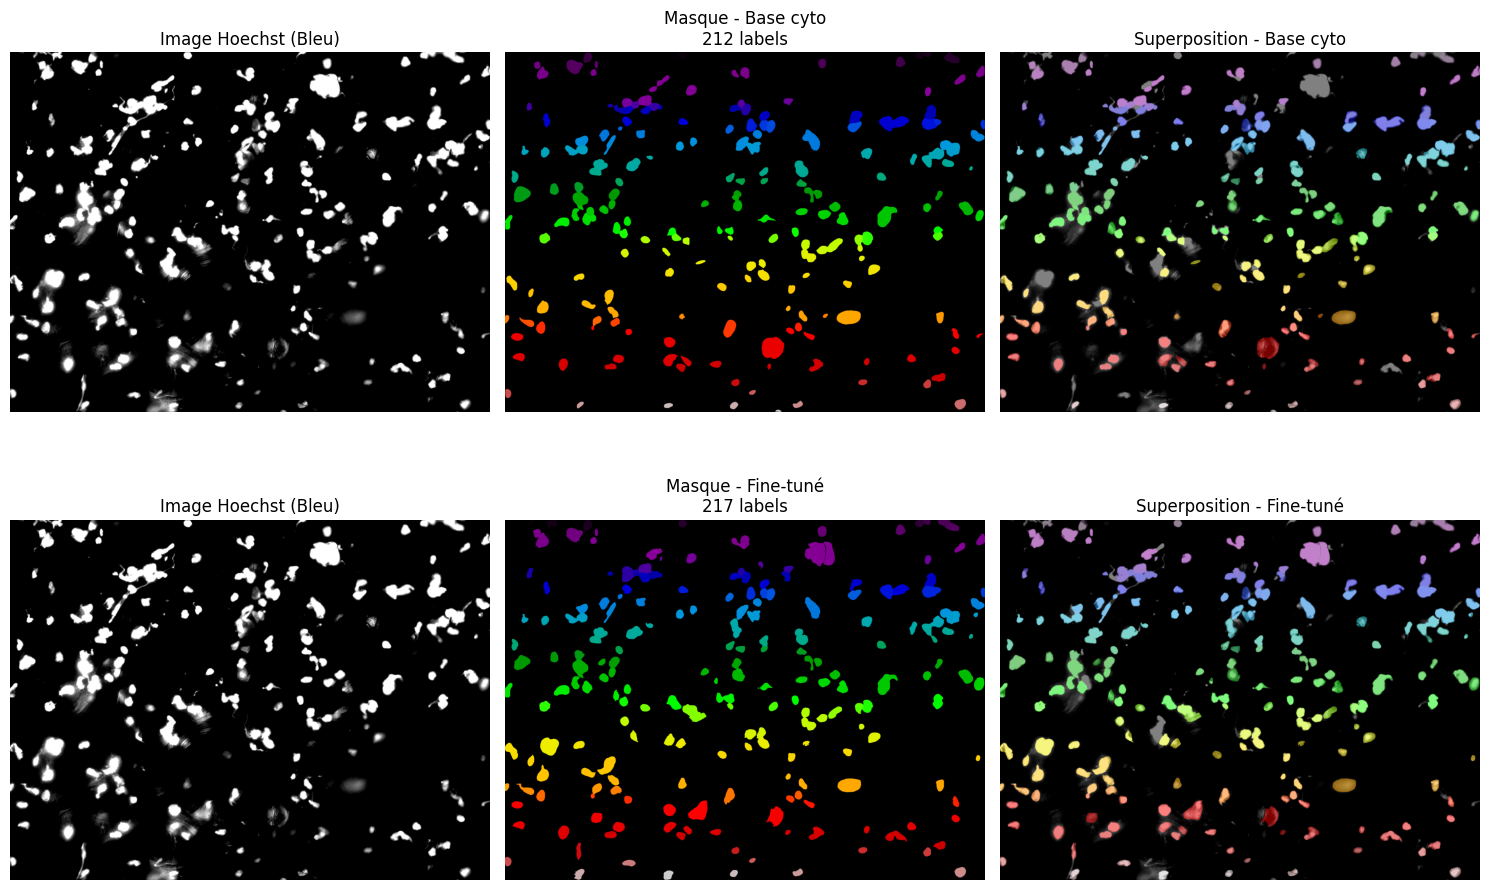

In [12]:
# 5) Visualisation
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Ligne 1 : modèle pré-entraîné
axes[0,0].imshow(test_img[..., 2], cmap="gray")
axes[0,0].set_title("Image Hoechst (Bleu)")
axes[0,0].axis("off")

axes[0,1].imshow(masks_pre[0], cmap="nipy_spectral")
axes[0,1].set_title(f"Masque - Base cyto\n{n_labels_pre} labels")
axes[0,1].axis("off")

axes[0,2].imshow(test_img[..., 2], cmap="gray")
axes[0,2].imshow(masks_pre[0], cmap="nipy_spectral", alpha=0.5)
axes[0,2].set_title("Superposition - Base cyto")
axes[0,2].axis("off")

# Ligne 2 : modèle fine-tuné
axes[1,0].imshow(test_img[..., 2], cmap="gray")
axes[1,0].set_title("Image Hoechst (Bleu)")
axes[1,0].axis("off")

axes[1,1].imshow(masks_ft[0], cmap="nipy_spectral")
axes[1,1].set_title(f"Masque - Fine-tuné\n{n_labels_ft} labels")
axes[1,1].axis("off")

axes[1,2].imshow(test_img[..., 2], cmap="gray")
axes[1,2].imshow(masks_ft[0], cmap="nipy_spectral", alpha=0.5)
axes[1,2].set_title("Superposition - Fine-tuné")
axes[1,2].axis("off")

plt.tight_layout()
plt.show()

/scratch/slurm_tmpdir/job_3924993/ipykernel_3795445/2522072079.py:29: UserWarning: The following kwargs were not used by contour: 'label'
  axes[3].contour(masks_pre[0], colors='red', linewidths=0.5, alpha=0.7, label="Base cyto")
/scratch/slurm_tmpdir/job_3924993/ipykernel_3795445/2522072079.py:30: UserWarning: The following kwargs were not used by contour: 'label'
  axes[3].contour(masks_ft[0], colors='lime', linewidths=0.5, alpha=0.7, label="Fine-tuné")


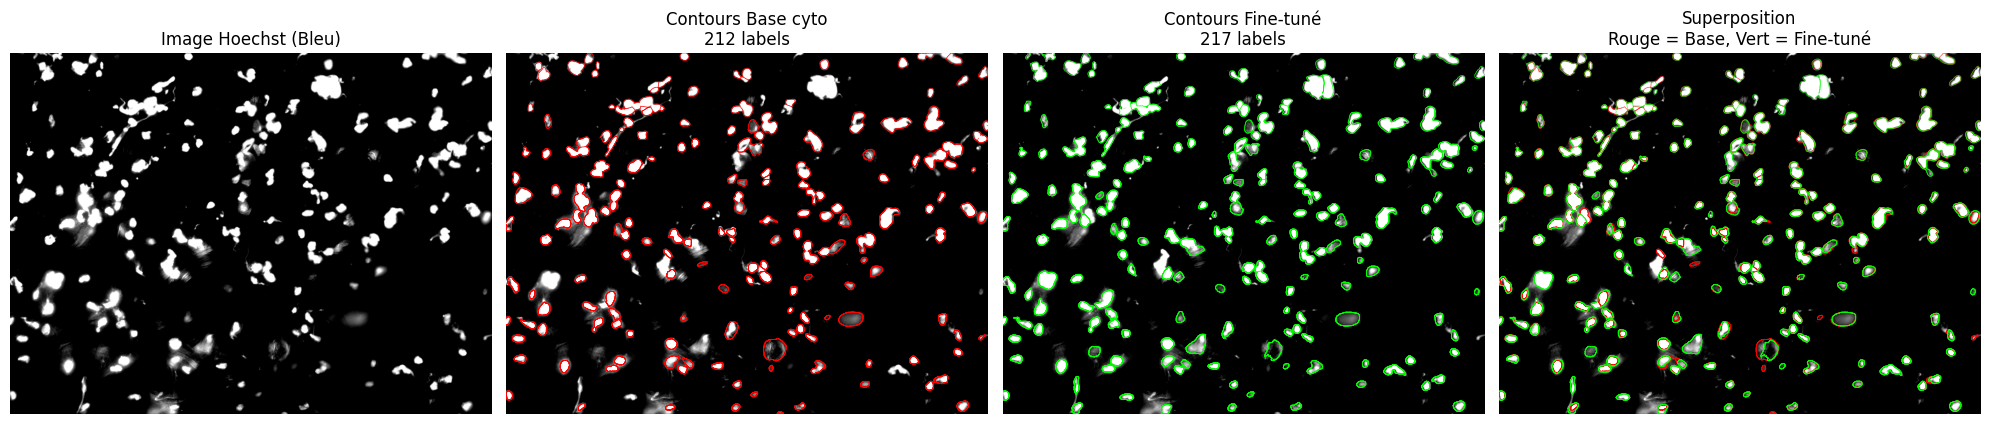

In [13]:
from cellpose import utils
import matplotlib.pyplot as plt

# Contours à partir des masques
outlines_pre = utils.masks_to_outlines(masks_pre[0])
outlines_ft  = utils.masks_to_outlines(masks_ft[0])

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# 1. Image brute
axes[0].imshow(test_img[..., 2], cmap="gray")
axes[0].set_title("Image Hoechst (Bleu)")
axes[0].axis("off")

# 2. Contours modèle de base
axes[1].imshow(test_img[..., 2], cmap="gray")
axes[1].contour(masks_pre[0], colors='red', linewidths=0.5)
axes[1].set_title(f"Contours Base cyto\n{n_labels_pre} labels")
axes[1].axis("off")

# 3. Contours modèle fine-tuné
axes[2].imshow(test_img[..., 2], cmap="gray")
axes[2].contour(masks_ft[0], colors='lime', linewidths=0.5)
axes[2].set_title(f"Contours Fine-tuné\n{n_labels_ft} labels")
axes[2].axis("off")

# 4. Comparaison superposée
axes[3].imshow(test_img[..., 2], cmap="gray")
axes[3].contour(masks_pre[0], colors='red', linewidths=0.5, alpha=0.7, label="Base cyto")
axes[3].contour(masks_ft[0], colors='lime', linewidths=0.5, alpha=0.7, label="Fine-tuné")
axes[3].set_title("Superposition\nRouge = Base, Vert = Fine-tuné")
axes[3].axis("off")

plt.tight_layout()
plt.show()


📊 Base cyto   : IoU=0.027, Dice=0.053
📊 Fine-tuné   : IoU=0.027, Dice=0.053


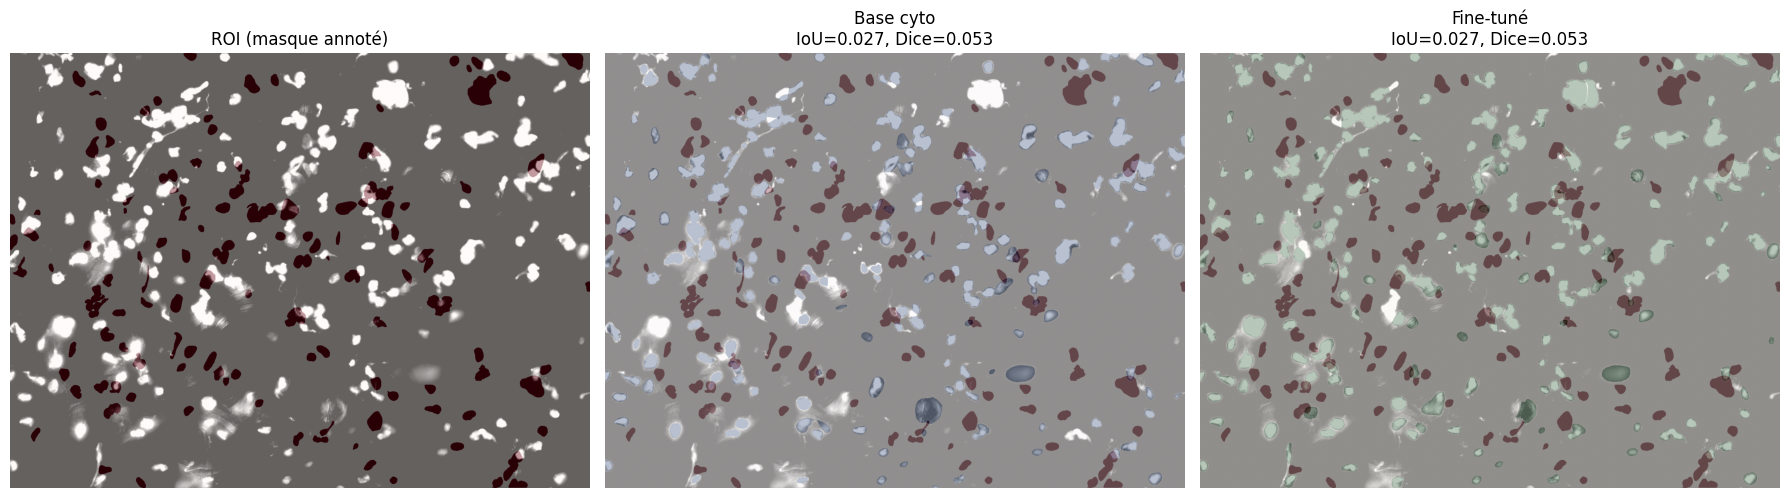

In [14]:
from sklearn.metrics import jaccard_score
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) Charger le ROI (masque annoté)
# -------------------------
roi_mask = train_masks[0]             # premier masque annoté
roi_mask = (roi_mask > 0).astype(np.uint8)  # binaire

# -------------------------
# 2) Binariser les prédictions
# -------------------------
pred_mask_pre = (masks_pre[0] > 0).astype(np.uint8)
pred_mask_ft  = (masks_ft[0]  > 0).astype(np.uint8)

# -------------------------
# 3) Métriques
# -------------------------
def dice_coef(y_true, y_pred):
    inter = np.logical_and(y_true, y_pred).sum()
    return (2. * inter) / (y_true.sum() + y_pred.sum() + 1e-8)

iou_pre  = jaccard_score(roi_mask.flatten(), pred_mask_pre.flatten())
iou_ft   = jaccard_score(roi_mask.flatten(), pred_mask_ft.flatten())
dice_pre = dice_coef(roi_mask, pred_mask_pre)
dice_ft  = dice_coef(roi_mask, pred_mask_ft)

print(f"📊 Base cyto   : IoU={iou_pre:.3f}, Dice={dice_pre:.3f}")
print(f"📊 Fine-tuné   : IoU={iou_ft:.3f}, Dice={dice_ft:.3f}")

# -------------------------
# 4) Visualisation
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ROI seul
axes[0].imshow(test_img[...,2], cmap="gray")
axes[0].imshow(roi_mask, cmap="Reds", alpha=0.4)
axes[0].set_title("ROI (masque annoté)")
axes[0].axis("off")

# Base cyto vs ROI
axes[1].imshow(test_img[...,2], cmap="gray")
axes[1].imshow(pred_mask_pre, cmap="Blues", alpha=0.4)
axes[1].imshow(roi_mask, cmap="Reds", alpha=0.3)
axes[1].set_title(f"Base cyto\nIoU={iou_pre:.3f}, Dice={dice_pre:.3f}")
axes[1].axis("off")

# Fine-tuné vs ROI
axes[2].imshow(test_img[...,2], cmap="gray")
axes[2].imshow(pred_mask_ft, cmap="Greens", alpha=0.4)
axes[2].imshow(roi_mask, cmap="Reds", alpha=0.3)
axes[2].set_title(f"Fine-tuné\nIoU={iou_ft:.3f}, Dice={dice_ft:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [15]:
# Pourcentages de correspondance avec le ROI (ground truth)
iou_pre_pct  = iou_pre  * 100
iou_ft_pct   = iou_ft   * 100
dice_pre_pct = dice_pre * 100
dice_ft_pct  = dice_ft  * 100

print(f"📊 Base cyto   : IoU={iou_pre:.3f} ({iou_pre_pct:.1f}%), Dice={dice_pre:.3f} ({dice_pre_pct:.1f}%)")
print(f"📊 Fine-tuné   : IoU={iou_ft:.3f} ({iou_ft_pct:.1f}%), Dice={dice_ft:.3f} ({dice_ft_pct:.1f}%)")


📊 Base cyto   : IoU=0.027 (2.7%), Dice=0.053 (5.3%)
📊 Fine-tuné   : IoU=0.027 (2.7%), Dice=0.053 (5.3%)


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score

# -------------------------
# Fonction Dice
# -------------------------
def dice_coef(y_true, y_pred):
    inter = np.logical_and(y_true, y_pred).sum()
    return (2.0 * inter) / (y_true.sum() + y_pred.sum() + 1e-8)

# -------------------------
# Boucle sur toutes les images
# -------------------------
results = []

for i, (img_name, msk_name) in enumerate(pairs):
    img = train_imgs[i]
    gt_mask = train_masks[i]

    # Ground truth binaire
    gt_bin = (gt_mask > 0).astype(np.uint8)

    # Prédiction modèle de base
    masks_pre, _, _ = model_pre.eval(
        [img],
        channel_axis=-1,
        diameter=None,
        normalize=True,
        resample=False
    )

    # Prédiction modèle fine-tuné
    masks_ft, _, _ = model_ft.eval(
        [img],
        channel_axis=-1,
        diameter=None,
        normalize=True,
        resample=False
    )

    pred_pre_bin = (masks_pre[0] > 0).astype(np.uint8)
    pred_ft_bin  = (masks_ft[0] > 0).astype(np.uint8)

    # Métriques
    iou_pre  = jaccard_score(gt_bin.flatten(), pred_pre_bin.flatten())
    iou_ft   = jaccard_score(gt_bin.flatten(), pred_ft_bin.flatten())
    dice_pre = dice_coef(gt_bin, pred_pre_bin)
    dice_ft  = dice_coef(gt_bin, pred_ft_bin)

    results.append({
        "image": img_name,
        "IoU_base": iou_pre,
        "IoU_finetuned": iou_ft,
        "Dice_base": dice_pre,
        "Dice_finetuned": dice_ft
    })

# -------------------------
# DataFrame résultats
# -------------------------
df_results = pd.DataFrame(results)
display(df_results)

print("\nMoyennes :")
print(df_results[["IoU_base", "IoU_finetuned", "Dice_base", "Dice_finetuned"]].mean())

,image,IoU_base,IoU_finetuned,Dice_base,Dice_finetuned
0,Trachea Hoechst Cazzini_06.tif,0.781878,0.790860,0.877589,0.883218
1,Trachea Hoechst Cazzini_07.tif,0.829899,0.791372,0.907043,0.883537
2,Trachea Hoechst Cazzini_08.tif,0.629319,0.711269,0.772493,0.831277
3,Trachea Hoechst Cazzini_09.tif,0.796813,0.759337,0.886918,0.863208
4,Trachea Hoechst Cazzini_10.tif,0.845426,0.764452,0.916239,0.866504
5,Trachea Hoechst Cazzini_11.tif,0.694790,0.758506,0.819913,0.862671
6,Trachea Hoechst Cazzini_12.tif,0.822732,0.797853,0.902746,0.887562
7,Trachea Hoechst Cazzini_13.tif,0.826982,0.764548,0.905298,0.866565
8,Trachea Hoechst Cazzini_14.tif,0.611843,0.738971,0.759184,0.849895
9,Trachea Hoechst Cazzini_15.tif,0.725563,0.733993,0.840958,0.846593



Moyennes :
IoU_base          0.637028
IoU_finetuned     0.764280
Dice_base         0.763810
Dice_finetuned    0.865934
dtype: float64


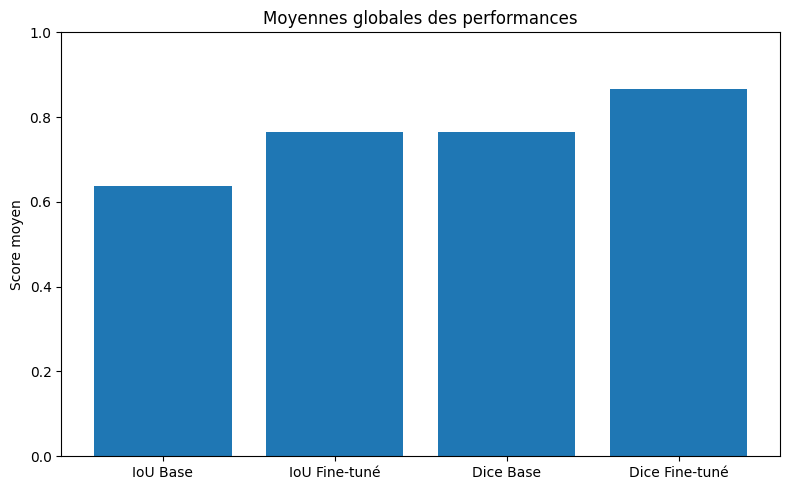

In [17]:
mean_vals = [
    df_results["IoU_base"].mean(),
    df_results["IoU_finetuned"].mean(),
    df_results["Dice_base"].mean(),
    df_results["Dice_finetuned"].mean()
]

labels = ["IoU Base", "IoU Fine-tuné", "Dice Base", "Dice Fine-tuné"]

plt.figure(figsize=(8, 5))
plt.bar(labels, mean_vals)
plt.ylabel("Score moyen")
plt.title("Moyennes globales des performances")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

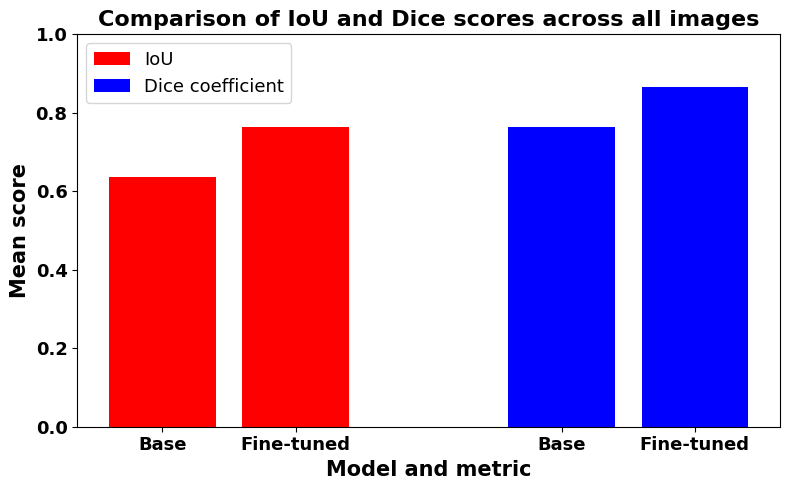

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Moyennes
mean_iou = [
    df_results["IoU_base"].mean(),
    df_results["IoU_finetuned"].mean()
]

mean_dice = [
    df_results["Dice_base"].mean(),
    df_results["Dice_finetuned"].mean()
]

# Positions
x_iou = np.array([0, 1])
x_dice = np.array([3, 4])

plt.figure(figsize=(8, 5))

# IoU en rouge
plt.bar(x_iou, mean_iou, color="red", label="IoU")

# Dice en bleu
plt.bar(x_dice, mean_dice, color="blue", label="Dice coefficient")

# Labels de l'axe x
xticks = list(x_iou) + list(x_dice)
xtick_labels = ["Base", "Fine-tuned", "Base", "Fine-tuned"]
plt.xticks(xticks, xtick_labels, fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")

plt.ylabel("Mean score", fontsize=15, fontweight="bold")
plt.xlabel("Model and metric", fontsize=15, fontweight="bold")
plt.title("Comparison of IoU and Dice scores across all images",
          fontsize=16, fontweight="bold")

plt.ylim(0, 1)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import pandas as pd

cell_count_results = []

for i, (img_name, msk_name) in enumerate(pairs):
    img = train_imgs[i]
    gt_mask = train_masks[i]

    # Prédictions
    masks_pre, _, _ = model_pre.eval(
        [img],
        channel_axis=-1,
        diameter=None,
        normalize=True,
        resample=False
    )

    masks_ft, _, _ = model_ft.eval(
        [img],
        channel_axis=-1,
        diameter=None,
        normalize=True,
        resample=False
    )

    # Comptage robuste
    gt_count = np.sum(np.unique(gt_mask) != 0)
    pre_count = np.sum(np.unique(masks_pre[0]) != 0)
    ft_count = np.sum(np.unique(masks_ft[0]) != 0)

    cell_count_results.append({
        "image": img_name,
        "Ground_truth": gt_count,
        "Base_model": pre_count,
        "Fine_tuned_model": ft_count
    })

df_counts = pd.DataFrame(cell_count_results)
display(df_counts)

,image,Ground_truth,Base_model,Fine_tuned_model
0,Trachea Hoechst Cazzini_06.tif,140,130,145
1,Trachea Hoechst Cazzini_07.tif,282,252,261
2,Trachea Hoechst Cazzini_08.tif,206,159,239
3,Trachea Hoechst Cazzini_09.tif,268,231,248
4,Trachea Hoechst Cazzini_10.tif,316,286,282
5,Trachea Hoechst Cazzini_11.tif,187,154,172
6,Trachea Hoechst Cazzini_12.tif,237,212,217
7,Trachea Hoechst Cazzini_13.tif,246,231,253
8,Trachea Hoechst Cazzini_14.tif,214,190,232
9,Trachea Hoechst Cazzini_15.tif,188,177,210


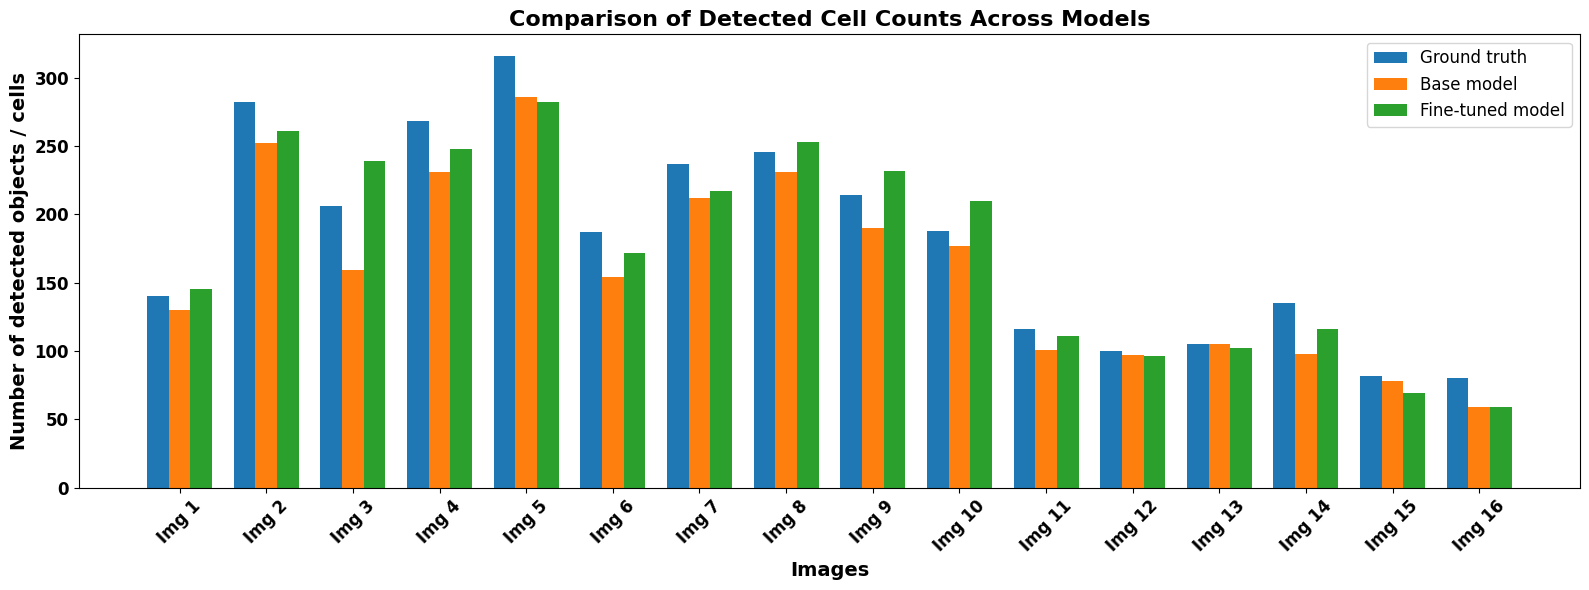

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(df_counts))
width = 0.25

plt.figure(figsize=(16, 6))

plt.bar(x - width, df_counts["Ground_truth"], width, label="Ground truth")
plt.bar(x, df_counts["Base_model"], width, label="Base model")
plt.bar(x + width, df_counts["Fine_tuned_model"], width, label="Fine-tuned model")

plt.xticks(x, [f"Img {i+1}" for i in range(len(df_counts))], rotation=45, fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.xlabel("Images", fontsize=14, fontweight="bold")
plt.ylabel("Number of detected objects / cells", fontsize=14, fontweight="bold")
plt.title("Comparison of Detected Cell Counts Across Models", fontsize=16, fontweight="bold")

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

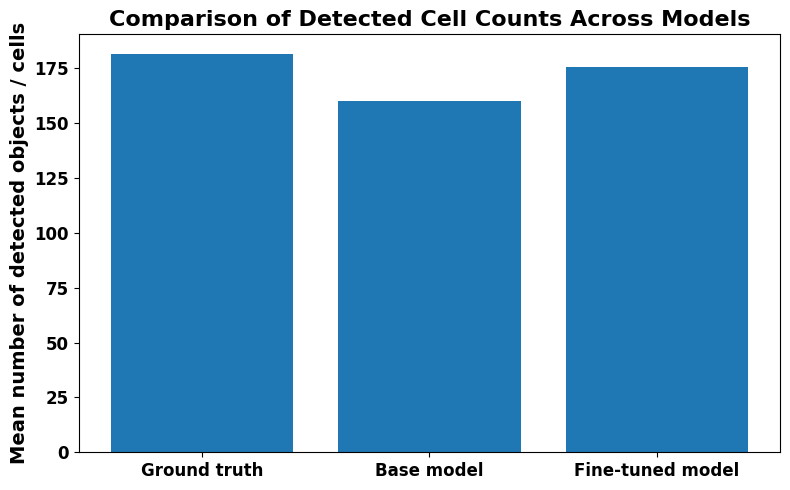

In [21]:
mean_counts = [
    df_counts["Ground_truth"].mean(),
    df_counts["Base_model"].mean(),
    df_counts["Fine_tuned_model"].mean()
]



labels = ["Ground truth", "Base model", "Fine-tuned model"]

plt.figure(figsize=(8, 5))
plt.bar(labels, mean_counts, capsize=6)

plt.ylabel("Mean number of detected objects / cells", fontsize=14, fontweight="bold")
plt.title("Comparison of Detected Cell Counts Across Models", fontsize=16, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

perf_results = []

for i, (img_name, msk_name) in enumerate(pairs):
    img = train_imgs[i]
    gt_mask = train_masks[i]

    # Ground truth binaire
    gt_bin = (gt_mask > 0).astype(np.uint8)

    # Prédictions
    masks_pre, _, _ = model_pre.eval(
        [img],
        channel_axis=-1,
        diameter=None,
        normalize=True,
        resample=False
    )

    masks_ft, _, _ = model_ft.eval(
        [img],
        channel_axis=-1,
        diameter=None,
        normalize=True,
        resample=False
    )

    pred_pre_bin = (masks_pre[0] > 0).astype(np.uint8)
    pred_ft_bin  = (masks_ft[0] > 0).astype(np.uint8)

    # Flatten
    y_true = gt_bin.flatten()
    y_pre  = pred_pre_bin.flatten()
    y_ft   = pred_ft_bin.flatten()

    # Métriques pretrained
    precision_pre = precision_score(y_true, y_pre, zero_division=0)
    recall_pre    = recall_score(y_true, y_pre, zero_division=0)
    f1_pre        = f1_score(y_true, y_pre, zero_division=0)

    # Métriques fine-tuned
    precision_ft = precision_score(y_true, y_ft, zero_division=0)
    recall_ft    = recall_score(y_true, y_ft, zero_division=0)
    f1_ft        = f1_score(y_true, y_ft, zero_division=0)

    perf_results.append({
        "image": img_name,
        "Precision_pretrained": precision_pre,
        "Recall_pretrained": recall_pre,
        "F1_pretrained": f1_pre,
        "Precision_finetuned": precision_ft,
        "Recall_finetuned": recall_ft,
        "F1_finetuned": f1_ft
    })

df_perf = pd.DataFrame(perf_results)
display(df_perf)

,image,Precision_pretrained,Recall_pretrained,F1_pretrained,Precision_finetuned,Recall_finetuned,F1_finetuned
0,Trachea Hoechst Cazzini_06.tif,0.976141,0.797112,0.877589,0.872321,0.894391,0.883218
1,Trachea Hoechst Cazzini_07.tif,0.985139,0.840420,0.907043,0.901826,0.865975,0.883537
2,Trachea Hoechst Cazzini_08.tif,0.986298,0.634870,0.772493,0.828826,0.833742,0.831277
3,Trachea Hoechst Cazzini_09.tif,0.988289,0.804408,0.886918,0.916667,0.815640,0.863208
4,Trachea Hoechst Cazzini_10.tif,0.974120,0.864851,0.916239,0.895046,0.839726,0.866504
5,Trachea Hoechst Cazzini_11.tif,0.982310,0.703594,0.819913,0.869582,0.855868,0.862671
6,Trachea Hoechst Cazzini_12.tif,0.985868,0.832550,0.902746,0.900034,0.875430,0.887562
7,Trachea Hoechst Cazzini_13.tif,0.974902,0.844971,0.905298,0.855145,0.878295,0.866565
8,Trachea Hoechst Cazzini_14.tif,0.988019,0.616417,0.759184,0.895818,0.808450,0.849895
9,Trachea Hoechst Cazzini_15.tif,0.975032,0.739298,0.840958,0.839970,0.853321,0.846593


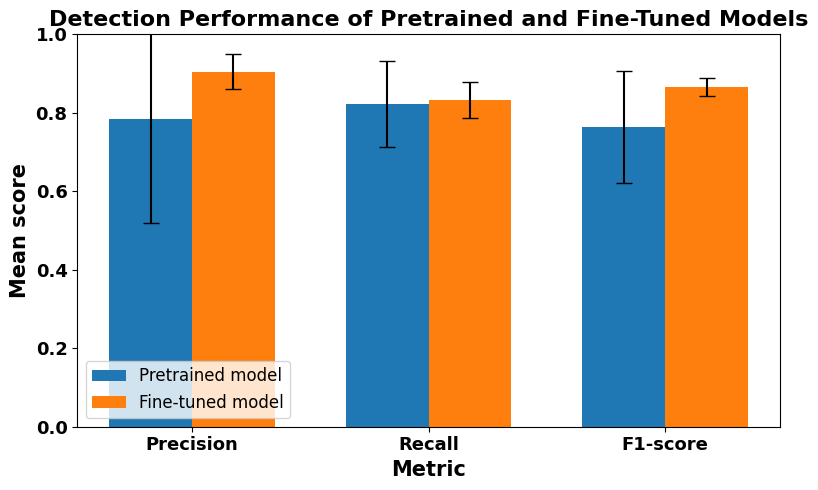

In [23]:
import numpy as np
import matplotlib.pyplot as plt

mean_pre = [
    df_perf["Precision_pretrained"].mean(),
    df_perf["Recall_pretrained"].mean(),
    df_perf["F1_pretrained"].mean()
]

mean_ft = [
    df_perf["Precision_finetuned"].mean(),
    df_perf["Recall_finetuned"].mean(),
    df_perf["F1_finetuned"].mean()
]

std_pre = [
    df_perf["Precision_pretrained"].std(),
    df_perf["Recall_pretrained"].std(),
    df_perf["F1_pretrained"].std()
]

std_ft = [
    df_perf["Precision_finetuned"].std(),
    df_perf["Recall_finetuned"].std(),
    df_perf["F1_finetuned"].std()
]

x = np.arange(3)
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, mean_pre, width, yerr=std_pre, capsize=6, label="Pretrained model")
plt.bar(x + width/2, mean_ft, width, yerr=std_ft, capsize=6, label="Fine-tuned model")

plt.xticks(x, ["Precision", "Recall", "F1-score"], fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")
plt.ylabel("Mean score", fontsize=15, fontweight="bold")
plt.xlabel("Metric", fontsize=15, fontweight="bold")
plt.title("Detection Performance of Pretrained and Fine-Tuned Models",
          fontsize=16, fontweight="bold")
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
summary_perf = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score"],
    "Pretrained_mean": mean_pre,
    "Fine_tuned_mean": mean_ft,
    "Pretrained_std": std_pre,
    "Fine_tuned_std": std_ft
})

display(summary_perf)

,Metric,Pretrained_mean,Fine_tuned_mean,Pretrained_std,Fine_tuned_std
0,Precision,0.785397,0.905260,0.266564,0.044914
1,Recall,0.822585,0.833094,0.108635,0.046470
2,F1-score,0.763810,0.865934,0.141744,0.023514


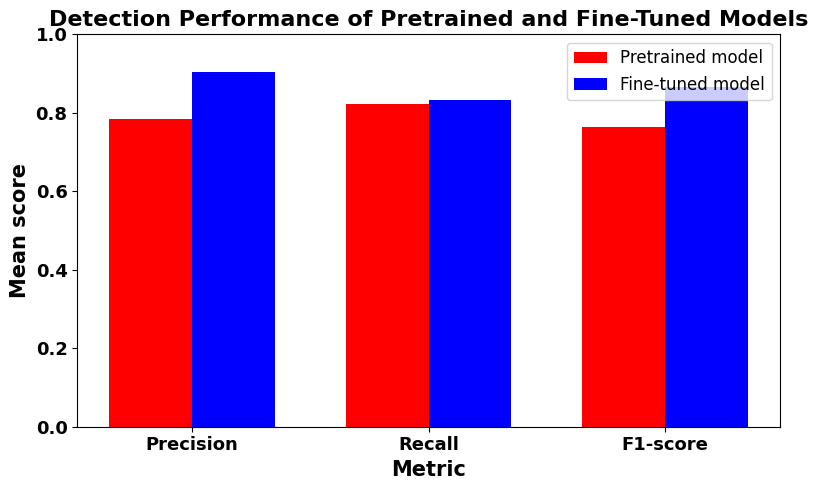

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(x - width/2, mean_pre, width, capsize=6, color="red", label="Pretrained model")
plt.bar(x + width/2, mean_ft, width, capsize=6, color="blue", label="Fine-tuned model")

plt.xticks(x, ["Precision", "Recall", "F1-score"], fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")
plt.ylabel("Mean score", fontsize=15, fontweight="bold")
plt.xlabel("Metric", fontsize=15, fontweight="bold")
plt.title("Detection Performance of Pretrained and Fine-Tuned Models",
          fontsize=16, fontweight="bold")
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from sklearn.metrics import jaccard_score, precision_score, recall_score, f1_score

# -----------------------------------
# Fonction Dice
# -----------------------------------
def dice_coef(y_true, y_pred):
    inter = np.logical_and(y_true, y_pred).sum()
    return (2.0 * inter) / (y_true.sum() + y_pred.sum() + 1e-8)

# -----------------------------------
# Fonction segmentation watershed
# -----------------------------------
def segment_watershed_nuclei(img_blue, min_distance=8):
    # seuillage Otsu
    thresh = threshold_otsu(img_blue)
    binary = img_blue > thresh

    # distance transform
    distance = ndi.distance_transform_edt(binary)

    # pics locaux = marqueurs
    coords = peak_local_max(distance, min_distance=min_distance, labels=binary)
    markers = np.zeros_like(img_blue, dtype=int)
    for i, (r, c) in enumerate(coords, start=1):
        markers[r, c] = i

    # watershed
    labels = watershed(-distance, markers, mask=binary)
    return labels, binary, distance

Detected nuclei (Watershed): 216


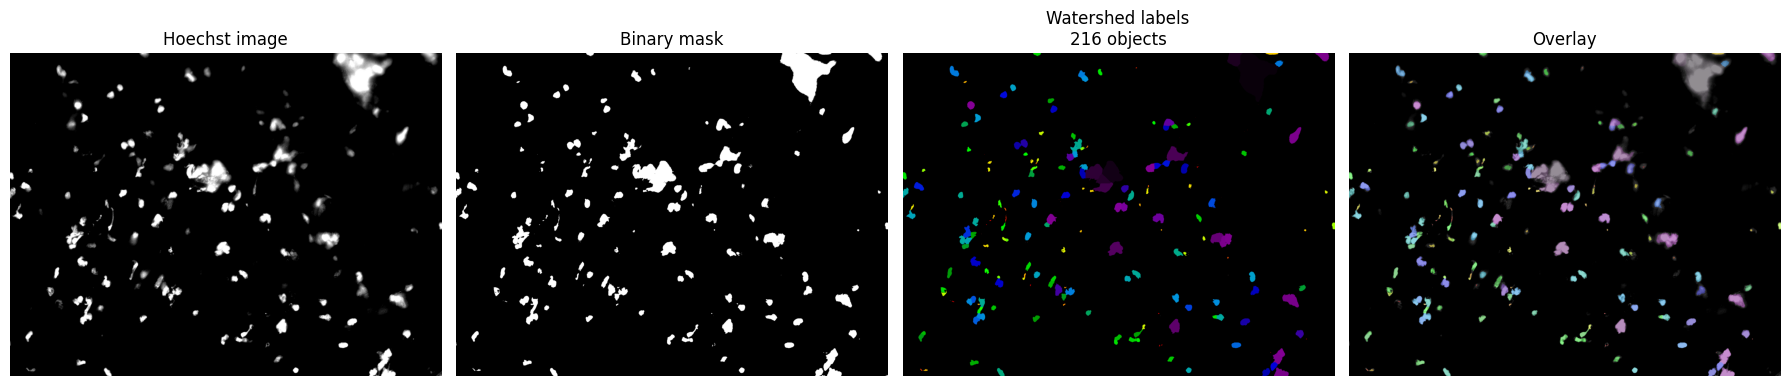

In [33]:
test_img = train_imgs[0]
img_blue = test_img[..., 2]

labels_ws, binary_ws, dist_ws = segment_watershed_nuclei(img_blue, min_distance=8)

n_labels_ws = np.sum(np.unique(labels_ws) != 0)
print("Detected nuclei (Watershed):", n_labels_ws)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_blue, cmap="gray")
axes[0].set_title("Hoechst image")
axes[0].axis("off")

axes[1].imshow(binary_ws, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

axes[2].imshow(labels_ws, cmap="nipy_spectral")
axes[2].set_title(f"Watershed labels\n{n_labels_ws} objects")
axes[2].axis("off")

axes[3].imshow(img_blue, cmap="gray")
axes[3].imshow(labels_ws, cmap="nipy_spectral", alpha=0.45)
axes[3].set_title("Overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [34]:
watershed_results = []

for i, (img_name, msk_name) in enumerate(pairs):
    img = train_imgs[i]
    gt_mask = train_masks[i]

    img_blue = img[..., 2]

    labels_ws, _, _ = segment_watershed_nuclei(img_blue, min_distance=8)

    gt_bin = (gt_mask > 0).astype(np.uint8)
    pred_bin = (labels_ws > 0).astype(np.uint8)

    y_true = gt_bin.flatten()
    y_pred = pred_bin.flatten()

    iou_ws = jaccard_score(y_true, y_pred)
    dice_ws = dice_coef(gt_bin, pred_bin)
    precision_ws = precision_score(y_true, y_pred, zero_division=0)
    recall_ws = recall_score(y_true, y_pred, zero_division=0)
    f1_ws = f1_score(y_true, y_pred, zero_division=0)

    gt_count = np.sum(np.unique(gt_mask) != 0)
    ws_count = np.sum(np.unique(labels_ws) != 0)

    watershed_results.append({
        "image": img_name,
        "IoU_Watershed": iou_ws,
        "Dice_Watershed": dice_ws,
        "Precision_Watershed": precision_ws,
        "Recall_Watershed": recall_ws,
        "F1_Watershed": f1_ws,
        "GT_count": gt_count,
        "Watershed_count": ws_count
    })

df_ws = pd.DataFrame(watershed_results)
display(df_ws)

print("\nMean Watershed metrics:")
print(df_ws[[
    "IoU_Watershed",
    "Dice_Watershed",
    "Precision_Watershed",
    "Recall_Watershed",
    "F1_Watershed"
]].mean())

,image,IoU_Watershed,Dice_Watershed,Precision_Watershed,Recall_Watershed,F1_Watershed,GT_count,Watershed_count
0,Trachea Hoechst Cazzini_06.tif,0.617640,0.763631,0.795001,0.734643,0.763631,140,216
1,Trachea Hoechst Cazzini_07.tif,0.629284,0.772467,0.831759,0.721065,0.772467,282,407
2,Trachea Hoechst Cazzini_08.tif,0.658048,0.793762,0.859659,0.737249,0.793762,206,393
3,Trachea Hoechst Cazzini_09.tif,0.622648,0.767447,0.861793,0.691720,0.767447,268,411
4,Trachea Hoechst Cazzini_10.tif,0.631736,0.774311,0.832573,0.723671,0.774311,316,447
5,Trachea Hoechst Cazzini_11.tif,0.688281,0.815363,0.873610,0.764397,0.815363,187,258
6,Trachea Hoechst Cazzini_12.tif,0.741209,0.851373,0.898057,0.809302,0.851373,237,355
7,Trachea Hoechst Cazzini_13.tif,0.715519,0.834172,0.831227,0.837137,0.834172,246,336
8,Trachea Hoechst Cazzini_14.tif,0.725878,0.841169,0.909299,0.782537,0.841169,214,319
9,Trachea Hoechst Cazzini_15.tif,0.731986,0.845256,0.884538,0.809315,0.845256,188,297



Mean Watershed metrics:
IoU_Watershed          0.631231
Dice_Watershed         0.771006
Precision_Watershed    0.909274
Recall_Watershed       0.684853
F1_Watershed           0.771006
dtype: float64


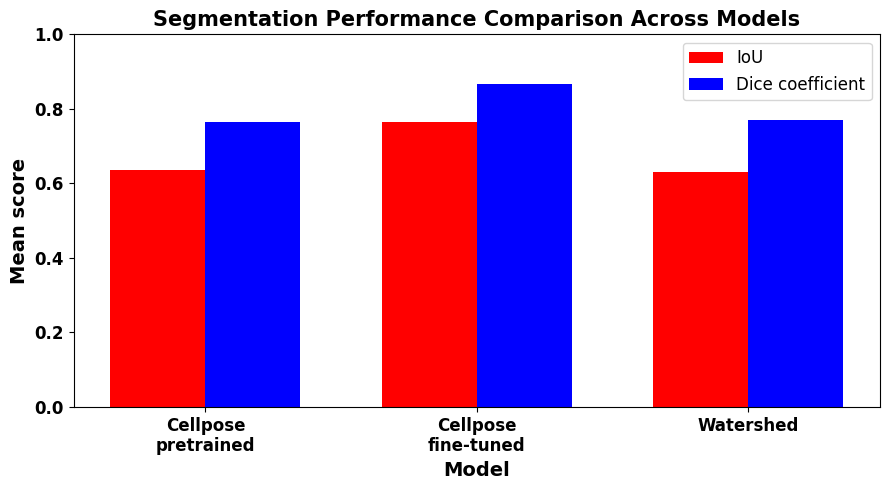

In [38]:
import numpy as np
import matplotlib.pyplot as plt

mean_iou = [
    df_results["IoU_base"].mean(),
    df_results["IoU_finetuned"].mean(),
    df_ws["IoU_Watershed"].mean()
]

mean_dice = [
    df_results["Dice_base"].mean(),
    df_results["Dice_finetuned"].mean(),
    df_ws["Dice_Watershed"].mean()
]

std_iou = [
    df_results["IoU_base"].std(),
    df_results["IoU_finetuned"].std(),
    df_ws["IoU_Watershed"].std()
]

std_dice = [
    df_results["Dice_base"].std(),
    df_results["Dice_finetuned"].std(),
    df_ws["Dice_Watershed"].std()
]

x = np.arange(3)
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, mean_iou, width, capsize=6, color="red", label="IoU")
plt.bar(x + width/2, mean_dice, width, capsize=6, color="blue", label="Dice coefficient")

plt.xticks(x, ["Cellpose\npretrained", "Cellpose\nfine-tuned", "Watershed"],
           fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")
plt.ylabel("Mean score", fontsize=14, fontweight="bold")
plt.xlabel("Model", fontsize=14, fontweight="bold")
plt.title("Segmentation Performance Comparison Across Models",
          fontsize=15, fontweight="bold")
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

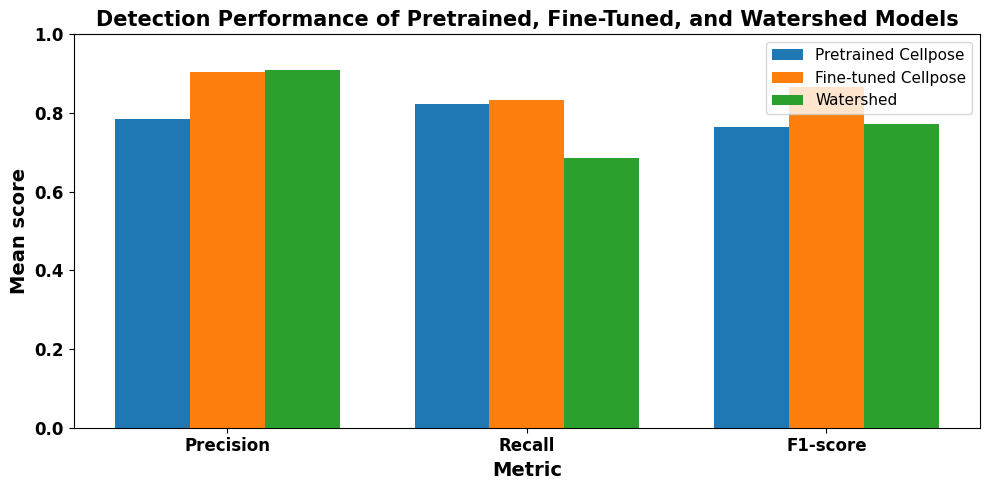

In [39]:
mean_pre = [
    df_perf["Precision_pretrained"].mean(),
    df_perf["Recall_pretrained"].mean(),
    df_perf["F1_pretrained"].mean()
]

mean_ft = [
    df_perf["Precision_finetuned"].mean(),
    df_perf["Recall_finetuned"].mean(),
    df_perf["F1_finetuned"].mean()
]

mean_ws = [
    df_ws["Precision_Watershed"].mean(),
    df_ws["Recall_Watershed"].mean(),
    df_ws["F1_Watershed"].mean()
]

std_pre = [
    df_perf["Precision_pretrained"].std(),
    df_perf["Recall_pretrained"].std(),
    df_perf["F1_pretrained"].std()
]

std_ft = [
    df_perf["Precision_finetuned"].std(),
    df_perf["Recall_finetuned"].std(),
    df_perf["F1_finetuned"].std()
]

std_ws = [
    df_ws["Precision_Watershed"].std(),
    df_ws["Recall_Watershed"].std(),
    df_ws["F1_Watershed"].std()
]

x = np.arange(3)
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, mean_pre, width, capsize=6, label="Pretrained Cellpose")
plt.bar(x, mean_ft, width, capsize=6, label="Fine-tuned Cellpose")
plt.bar(x + width, mean_ws, width, capsize=6, label="Watershed")

plt.xticks(x, ["Precision", "Recall", "F1-score"], fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")
plt.ylabel("Mean score", fontsize=14, fontweight="bold")
plt.xlabel("Metric", fontsize=14, fontweight="bold")
plt.title("Detection Performance of Pretrained, Fine-Tuned, and Watershed Models",
          fontsize=15, fontweight="bold")
plt.ylim(0, 1)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

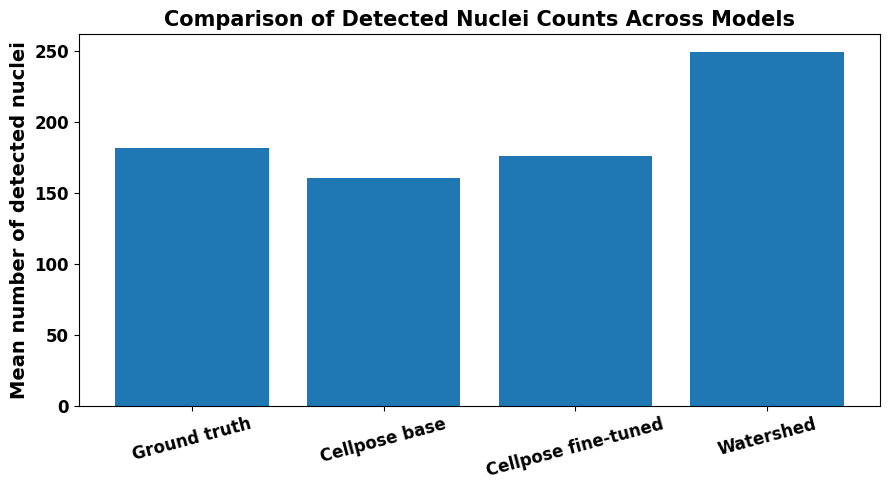

In [40]:
mean_counts = [
    df_counts["Ground_truth"].mean(),
    df_counts["Base_model"].mean(),
    df_counts["Fine_tuned_model"].mean(),
    df_ws["Watershed_count"].mean()
]

std_counts = [
    df_counts["Ground_truth"].std(),
    df_counts["Base_model"].std(),
    df_counts["Fine_tuned_model"].std(),
    df_ws["Watershed_count"].std()
]

labels = ["Ground truth", "Cellpose base", "Cellpose fine-tuned", "Watershed"]

plt.figure(figsize=(9, 5))
plt.bar(labels, mean_counts, capsize=6)

plt.ylabel("Mean number of detected nuclei", fontsize=14, fontweight="bold")
plt.title("Comparison of Detected Nuclei Counts Across Models", fontsize=15, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold", rotation=15)
plt.yticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()